
# Multiclass PPE Classification Using Transfer Learning

## Updated Version — Construction PPE Dataset

This notebook downloads the **Ultralytics Construction-PPE dataset**, reads its YOLO annotations, converts each annotated bounding box into a cropped classification image, and trains a **MobileNetV2 multiclass classifier**.

### Workflow

**Construction PPE YOLO dataset → bounding-box crops → class folders → MobileNetV2 → multiclass prediction**

This is a simpler alternative to training a full YOLO object detector.


### Fixes & improvements applied in this version

- **Root cause of the error:** the crop-conversion step looked for each image next to its label file. This dataset (like most Ultralytics/Roboflow YOLO exports) actually keeps images and labels in *parallel* `images/` and `labels/` folders, so the image was never found, 0 crops were produced, and every cell after it failed (`FileNotFoundError` on `ppe_classification_dataset`). Fixed by matching `labels/<split>/name.txt` to `images/<split>/name.jpg`.
- **Train/val/test leakage:** crops are now kept in the dataset's original train/val/test split (folders), instead of merging every crop and letting Keras re-split them randomly. That avoids near-duplicate crops from the same source photo landing in both the training and validation sets.
- **Held-out test set:** final evaluation (accuracy, classification report, confusion matrix) now runs on the untouched `test` split instead of the `val` split that was already used for early stopping.
- **Class imbalance:** added `class_weight` (computed from the training folder counts) so the model doesn't just learn to predict the most common classes.


## 1. Install / Import Required Libraries

In [1]:

# For Google Colab, run this cell if required:
# !pip install -q tensorflow pillow pyyaml scikit-learn seaborn

import os
import random
import shutil
import urllib.request
import zipfile
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Download the Construction PPE Dataset

In [2]:

DATA_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"

WORK = Path("/content") if Path("/content").exists() else Path.cwd()

DATA_DIR = WORK / "ppe_data"
ZIP_PATH = WORK / "construction-ppe.zip"


def find_yaml(root):
    hits = sorted(Path(root).rglob("data.yaml"))
    return hits[0] if hits else None


if find_yaml(DATA_DIR) is None:

    if not ZIP_PATH.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
        print("Download complete.")

    print("Extracting dataset...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

    print("Extraction complete.")


SRC_YAML = find_yaml(DATA_DIR)

if SRC_YAML is None:
    raise FileNotFoundError(
        "data.yaml was not found. Check that the dataset downloaded correctly."
    )

ROOT = SRC_YAML.parent

print("Dataset root:", ROOT)


Download complete.
Extracting dataset...
Extraction complete.
Dataset root: /content/ppe_data


## 3. Read the Dataset Classes

In [3]:

with open(SRC_YAML, "r", encoding="utf-8") as f:
    src_cfg = yaml.safe_load(f)

names = src_cfg["names"]

if isinstance(names, list):
    names = {i: n for i, n in enumerate(names)}

names = {int(k): v for k, v in names.items()}

NAME2ID = {v.lower(): k for k, v in names.items()}

print(f"{len(names)} classes:")
for class_id, class_name in names.items():
    print(f"{class_id}: {class_name}")


11 classes:
0: helmet
1: gloves
2: vest
3: boots
4: goggles
5: none
6: Person
7: no_helmet
8: no_goggle
9: no_gloves
10: no_boots



## 4. Convert YOLO Bounding Boxes into Classification Images

The original dataset contains images plus YOLO `.txt` annotations.

Each annotation has:

```text
class_id x_center y_center width height
```

We crop each bounding box and save it into a folder named after its class.

For example:

```text
ppe_classification_dataset/
    Helmet/
    Gloves/
    Vest/
    Boots/
    Goggles/
    ...
```

This makes the dataset compatible with standard image classification.


In [4]:

CLASSIFICATION_DIR = WORK / "ppe_classification_dataset"

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

SPLIT_NAMES = {"train", "val", "test"}


def find_image_for_label(label_path):
    """
    Locate the image that matches a YOLO label file.

    Ultralytics / Roboflow style datasets keep images and labels in
    *parallel* folders, e.g.:
        images/train/img001.jpg
        labels/train/img001.txt
    (same filename, different parent folder) rather than side-by-side
    in the same folder. The original code only tried
    `label_path.with_suffix(ext)`, which looks for the image inside the
    *labels* folder and never finds it -> 0 crops are produced and every
    later cell fails. We try the images/<->labels swap first, and fall
    back to a same-folder match for datasets that are laid out that way.
    """
    rel = label_path.relative_to(ROOT)
    parts = list(rel.parts)

    candidates = []

    if "labels" in parts:
        swapped = parts.copy()
        swapped[parts.index("labels")] = "images"
        candidates.append(ROOT / Path(*swapped))

    candidates.append(label_path)  # same-folder fallback

    for candidate in candidates:
        for ext in IMAGE_EXTENSIONS:
            img = candidate.with_suffix(ext)
            if img.exists():
                return img

    return None


def get_split(image_path):
    """
    Keep each crop in the same train/val/test split as its source image,
    instead of merging everything and re-splitting randomly later. That
    matters here because one photo can produce several crops (helmet,
    vest, gloves, ...); if those crops were re-split independently,
    near-duplicate crops from the same photo could end up in both the
    training and validation sets, inflating validation accuracy.
    """
    parts = image_path.relative_to(ROOT).parts
    for split in SPLIT_NAMES:
        if split in parts:
            return split
    return "train"


def convert_yolo_to_classification():

    total_crops = 0
    label_files = sorted(ROOT.rglob("*.txt"))

    print("Found label files:", len(label_files))

    for label_path in label_files:

        if label_path.name == "classes.txt":
            continue

        image_path = find_image_for_label(label_path)

        if image_path is None:
            continue

        split = get_split(image_path)

        try:
            image = Image.open(image_path).convert("RGB")
            width, height = image.size

            with open(label_path, "r", encoding="utf-8") as f:
                lines = [line.strip() for line in f if line.strip()]

            for box_id, line in enumerate(lines):

                parts = line.split()

                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))

                xc = float(parts[1])
                yc = float(parts[2])
                bw = float(parts[3])
                bh = float(parts[4])

                if class_id not in names:
                    continue

                class_name = names[class_id]

                # YOLO normalized coordinates -> pixel coordinates
                x_center = xc * width
                y_center = yc * height

                box_width = bw * width
                box_height = bh * height

                # Add a small context margin around tight boxes. Small
                # objects (goggles, gloves) get cropped very tightly by
                # the raw YOLO box, then blown up to 224x224 and lose
                # detail. A ~15% margin keeps a bit of surrounding
                # context and reduces that upscaling blur.
                CROP_MARGIN = 0.15
                box_width_padded = box_width * (1 + CROP_MARGIN)
                box_height_padded = box_height * (1 + CROP_MARGIN)

                x1 = int(x_center - box_width_padded / 2)
                y1 = int(y_center - box_height_padded / 2)
                x2 = int(x_center + box_width_padded / 2)
                y2 = int(y_center + box_height_padded / 2)

                # Clip coordinates to image boundaries
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(width, x2)
                y2 = min(height, y2)

                if x2 <= x1 or y2 <= y1:
                    continue

                crop = image.crop((x1, y1, x2, y2))

                class_dir = CLASSIFICATION_DIR / split / class_name
                class_dir.mkdir(parents=True, exist_ok=True)

                output_name = f"{image_path.stem}_box{box_id}.jpg"
                output_path = class_dir / output_name

                crop.save(output_path, quality=95)

                total_crops += 1

        except Exception as e:
            print(f"Skipping {image_path}: {e}")

    print()
    print("Conversion complete!")
    print("Total classification crops:", total_crops)
    print("Output:", CLASSIFICATION_DIR)


convert_yolo_to_classification()


Found label files: 1426

Conversion complete!
Total classification crops: 11521
Output: /content/ppe_classification_dataset


## 5. Check the New Classification Dataset

In [5]:

class_counts = {}

for split_dir in sorted(CLASSIFICATION_DIR.iterdir()):
    if not split_dir.is_dir():
        continue
    for folder in sorted(split_dir.iterdir()):
        if folder.is_dir():
            count = sum(
                1 for f in folder.iterdir()
                if f.suffix.lower() in IMAGE_EXTENSIONS
            )
            class_counts[folder.name] = class_counts.get(folder.name, 0) + count

counts_df = (
    pd.DataFrame({
        "Class": list(class_counts.keys()),
        "Images": list(class_counts.values())
    })
    .sort_values("Images", ascending=False)
)

display(counts_df)

print("Total classification images:", counts_df["Images"].sum())
print("Number of classes:", len(counts_df))


,Class,Images
0,Person,2245
4,helmet,1734
10,vest,1618
1,boots,1597
2,gloves,1445
9,none,797
6,no_gloves,556
3,goggles,518
8,no_helmet,485
7,no_goggle,411


Total classification images: 11521
Number of classes: 11


## 6. Visualize Class Distribution

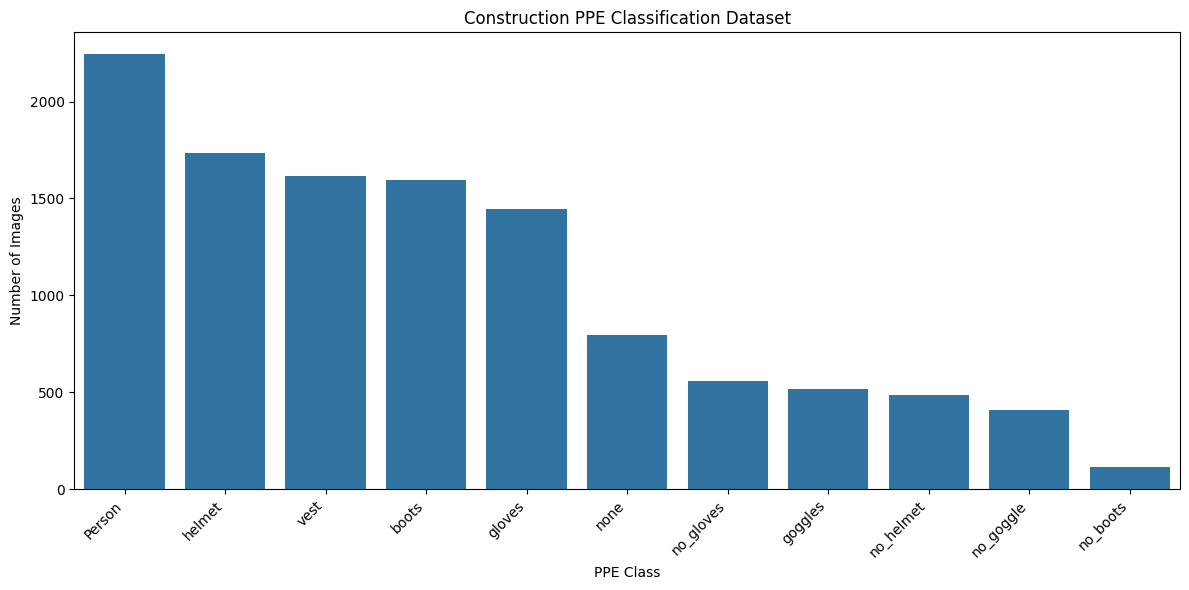

In [6]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=counts_df,
    x="Class",
    y="Images"
)

plt.xticks(rotation=45, ha="right")
plt.title("Construction PPE Classification Dataset")
plt.xlabel("PPE Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## 7. Display Sample Images

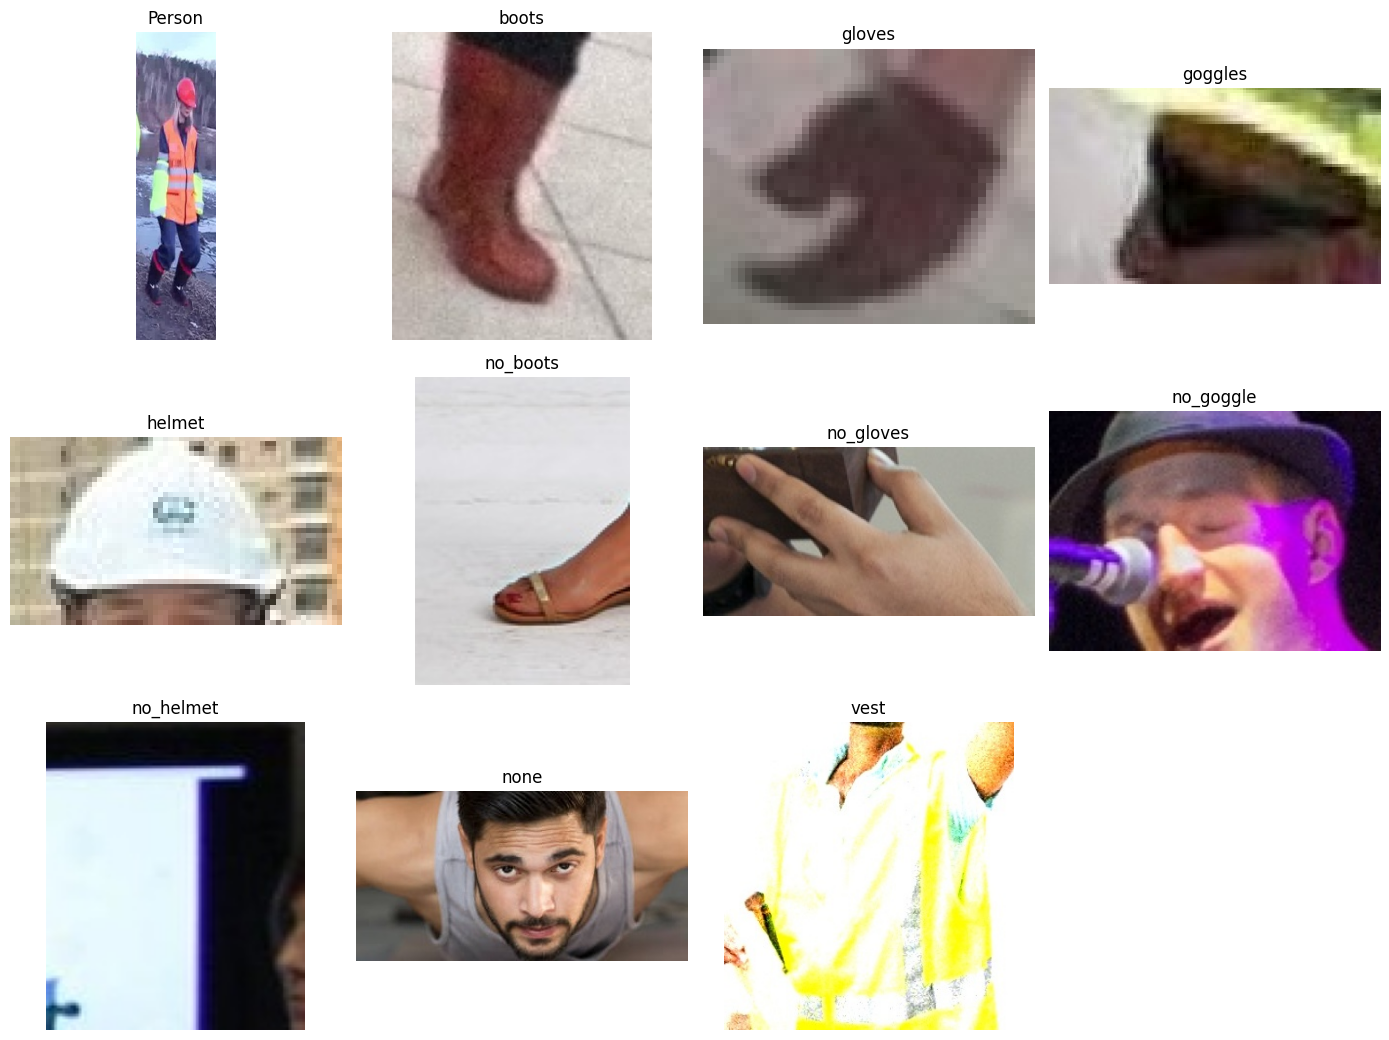

In [7]:

sample_records = []

for class_name in sorted(class_counts):
    class_dir = CLASSIFICATION_DIR / "train" / class_name

    if not class_dir.exists():
        continue

    files = [
        f for f in class_dir.iterdir()
        if f.suffix.lower() in IMAGE_EXTENSIONS
    ]

    if files:
        sample_records.append((class_name, random.choice(files)))


n = len(sample_records)
cols = 4
rows = int(np.ceil(n / cols))

plt.figure(figsize=(14, 3.5 * rows))

for i, (class_name, image_path) in enumerate(sample_records):
    image = Image.open(image_path)

    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 8. Load Training and Validation Data

In [8]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# We already preserved the dataset's own train/val/test split when the
# crops were created (see step 4), so we load each folder directly
# instead of using validation_split to carve a validation set out of
# the merged crops. This avoids near-duplicate crops from the same
# source photo leaking between the training and validation sets.

train_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_DIR / "train",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_DIR / "val",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# A genuine held-out test set, used later for the final evaluation
# instead of reusing the validation set that guided early stopping.
test_ds = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_DIR / "test",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)


Found 9098 files belonging to 11 classes.
Found 1172 files belonging to 11 classes.
Found 1251 files belonging to 11 classes.
Classes: ['Person', 'boots', 'gloves', 'goggles', 'helmet', 'no_boots', 'no_gloves', 'no_goggle', 'no_helmet', 'none', 'vest']
Number of classes: 11


## 9. Optimize the TensorFlow Input Pipeline

In [9]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


## 8b. Class-Balanced Resampling

`class_weight` alone (used later) rarely fixes severe imbalance on its own — `no_boots` has ~14x fewer training crops than `Person`. Here we build one `tf.data` pipeline per class and mix them with `sample_from_datasets`, so each training batch sees a much more even spread of classes. We use inverse-**sqrt** weighting rather than fully equalizing classes, so the smallest class (`no_boots`, 115 images) isn't duplicated so much that the model just memorizes it.

In [10]:

# Per-class file counts (also used for the resampling weights below).
train_class_counts = {
    class_name: len(list((CLASSIFICATION_DIR / "train" / class_name).glob("*")))
    for class_name in class_names
}
total_train_images = sum(train_class_counts.values())

IMAGE_EXTENSIONS_STR = "*"


def make_class_dataset(class_dir, label, img_size):
    files = tf.data.Dataset.list_files(str(class_dir / "*"), shuffle=True)

    def load(path):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        return img, label

    # repeat() so sample_from_datasets never runs out of a rare class
    return files.map(load, num_parallel_calls=AUTOTUNE).repeat()


class_datasets = []
sampling_weights = []

for i, class_name in enumerate(class_names):
    class_dir = CLASSIFICATION_DIR / "train" / class_name
    count = train_class_counts[class_name]

    class_datasets.append(make_class_dataset(class_dir, i, IMG_SIZE))
    sampling_weights.append(1.0 / np.sqrt(count))

sampling_weights = np.array(sampling_weights)
sampling_weights = sampling_weights / sampling_weights.sum()

print("Resampling weights (higher = oversampled more):")
for class_name, w in zip(class_names, sampling_weights):
    print(f"  {class_name}: {w:.4f}")

# A full pass over the (now class-balanced) stream, sized to roughly
# match one epoch over the original training set.
STEPS_PER_EPOCH = max(1, total_train_images // BATCH_SIZE)

train_ds_balanced = tf.data.Dataset.sample_from_datasets(
    class_datasets,
    weights=sampling_weights.tolist(),
    seed=SEED,
    stop_on_empty_dataset=False,
)

train_ds_balanced = (
    train_ds_balanced
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Steps per epoch (balanced training stream):", STEPS_PER_EPOCH)


Resampling weights (higher = oversampled more):
  Person: 0.0491
  boots: 0.0588
  gloves: 0.0611
  goggles: 0.1010
  helmet: 0.0564
  no_boots: 0.2203
  no_gloves: 0.0983
  no_goggle: 0.1126
  no_helmet: 0.1033
  none: 0.0810
  vest: 0.0580
Steps per epoch (balanced training stream): 284


## 10. Data Augmentation

In [11]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomBrightness(0.10),
    ],
    name="data_augmentation"
)


## 11. Build MobileNetV2 Transfer-Learning Model

In [12]:

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# First train only the new classification head.
base_model.trainable = False


inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

# A small hidden layer gives the head more capacity to separate the
# 11 fine-grained classes than pooled-features -> softmax directly.
x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,747 (9.88 MB)

 Trainable params: 330,763 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 12. Train the Classification Head

In [13]:

# NOTE: train_class_counts / total_train_images were already computed
# in the resampling cell above. class_weight is no longer needed here
# because train_ds_balanced already oversamples the rare classes -
# combining both would over-correct.

EPOCHS_HEAD = 15

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "best_ppe_classifier.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


history_head = model.fit(
    train_ds_balanced,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


Epoch 1/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - accuracy: 0.6028 - loss: 1.2919 - val_accuracy: 0.6911 - val_loss: 0.9597 - learning_rate: 0.0010
Epoch 2/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.7047 - loss: 0.9468 - val_accuracy: 0.7628 - val_loss: 0.7380 - learning_rate: 0.0010
Epoch 3/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.7382 - loss: 0.8326 - val_accuracy: 0.7696 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 4/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - accuracy: 0.7563 - loss: 0.7903 - val_accuracy: 0.7790 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 5/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.7631 - loss: 0.7544 - val_accuracy: 0.7918 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 6/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - accuracy: 0.7727 - loss: 0.7314 - val_accuracy: 0.8012 - val_loss: 0.6838 - learning_rate: 0.0010
Epoch 7/15
284/284 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.7698 - l

## 13. Fine-Tune MobileNetV2

In [14]:

# Unfreeze more of MobileNetV2 than before (last 80 layers instead of
# 30). The previous run only unfroze the last 30 layers, used a very
# low 1e-5 LR, and early-stopped after 3 epochs - it barely moved
# (0.76 -> 0.82 val accuracy). Give it more room and a bit more LR to
# actually adapt the backbone to PPE crops.
base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


EPOCHS_FINE = 20

fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "best_ppe_classifier.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_fine = model.fit(
    train_ds_balanced,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=fine_tune_callbacks
)


Epoch 1/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 59s 146ms/step - accuracy: 0.6903 - loss: 1.0311 - val_accuracy: 0.7961 - val_loss: 0.7925 - learning_rate: 3.0000e-05
Epoch 2/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 39s 139ms/step - accuracy: 0.7821 - loss: 0.7073 - val_accuracy: 0.8114 - val_loss: 0.6951 - learning_rate: 3.0000e-05
Epoch 3/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 39s 136ms/step - accuracy: 0.8158 - loss: 0.5978 - val_accuracy: 0.8106 - val_loss: 0.7234 - learning_rate: 3.0000e-05
Epoch 4/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.8376 - loss: 0.5419 - val_accuracy: 0.8157 - val_loss: 0.7007 - learning_rate: 3.0000e-05
Epoch 5/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.8443 - loss: 0.5185 - val_accuracy: 0.8276 - val_loss: 0.6383 - learning_rate: 9.0000e-06
Epoch 6/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step - accuracy: 0.8440 - loss: 0.5148 - val_accuracy: 0.8285 - val_loss: 0.6165 - learning_rate: 9.0000e-06
Epoch 7/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 39s 13

## 14. Plot Training Accuracy and Loss

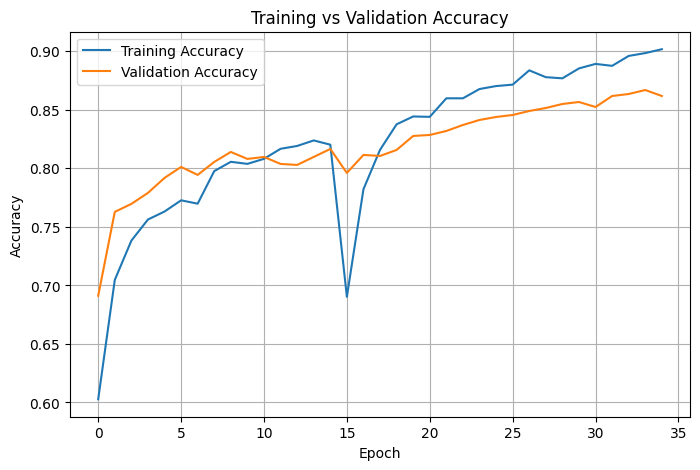

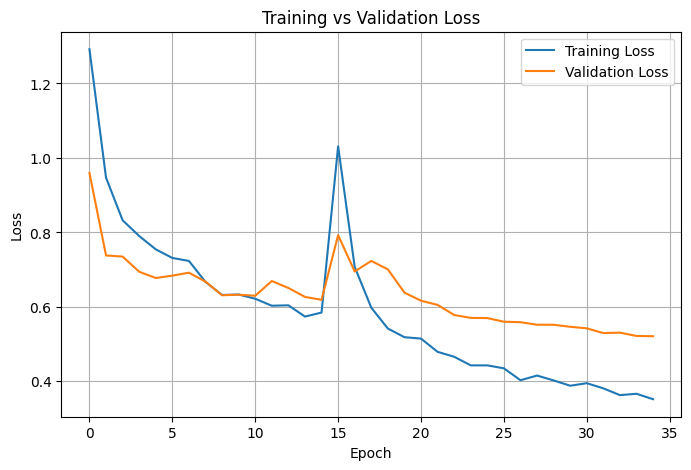

In [15]:

def combine_history(h1, h2):
    combined = {}

    for key in h1.history:
        combined[key] = (
            h1.history[key]
            + h2.history.get(key, [])
        )

    return combined


history = combine_history(
    history_head,
    history_fine
)


plt.figure(figsize=(8, 5))

plt.plot(
    history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history["loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 15. Evaluate the Model

Evaluated on the held-out **test** split, which the model never saw during training or early stopping.


In [16]:

# Evaluate on the held-out TEST set (never seen during training or for
# early-stopping decisions) rather than val_ds, which was already used
# to guide training and would give an optimistic estimate.
loss, accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8569 - loss: 0.5325
Test Loss: 0.5325
Test Accuracy: 0.8569


## 16. Generate Predictions

Predictions on the held-out **test** split.


In [17]:

y_true = []
y_pred = []

for images, labels in test_ds:

    probabilities = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)


y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated.")
print("Number of test samples:", len(y_true))


Predictions generated.
Number of test samples: 1251


## 17. Classification Report

In [18]:

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

      Person     0.9342    0.9619    0.9478       236
       boots     0.9341    0.8057    0.8651       211
      gloves     0.7912    0.8834    0.8348       163
     goggles     0.9608    0.9423    0.9515        52
      helmet     0.9622    0.9271    0.9443       192
    no_boots     0.4783    0.4783    0.4783        23
   no_gloves     0.6154    0.6897    0.6504        58
   no_goggle     0.8261    0.5758    0.6786        33
   no_helmet     0.5636    0.7750    0.6526        40
        none     0.6562    0.6462    0.6512        65
        vest     0.9045    0.9045    0.9045       178

    accuracy                         0.8569      1251
   macro avg     0.7842    0.7809    0.7781      1251
weighted avg     0.8644    0.8569    0.8582      1251



## 18. Confusion Matrix

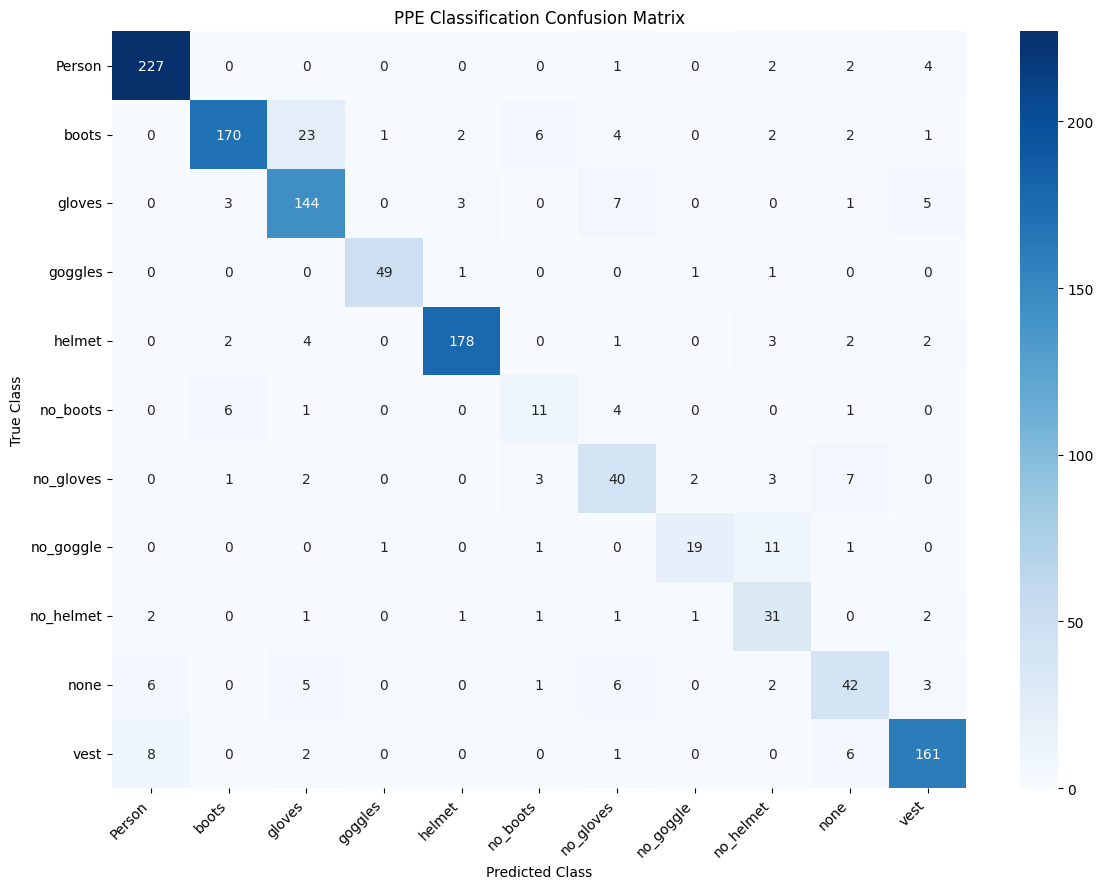

In [19]:

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("PPE Classification Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


**Reading this matrix:** check specifically how much confusion there is between `none` and the `no_helmet` / `no_boots` / `no_goggle` / `no_gloves` classes. A crop labeled `none` (no PPE visible) and one labeled `no_helmet` (missing specifically a helmet) can look near-identical without the full image for context, which is a likely source of the low F1 scores on those classes. If the confusion is concentrated there, consider merging `none` into the closest `no_X` class, or dropping it, rather than trying to fix it purely with more training.

## 19. Per-Class Precision, Recall and F1 Score

In [20]:

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report).T

display(
    metrics_df.loc[
        class_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].round(4)
)


,precision,recall,f1-score,support
Person,0.9342,0.9619,0.9478,236.0
boots,0.9341,0.8057,0.8651,211.0
gloves,0.7912,0.8834,0.8348,163.0
goggles,0.9608,0.9423,0.9515,52.0
helmet,0.9622,0.9271,0.9443,192.0
no_boots,0.4783,0.4783,0.4783,23.0
no_gloves,0.6154,0.6897,0.6504,58.0
no_goggle,0.8261,0.5758,0.6786,33.0
no_helmet,0.5636,0.7750,0.6526,40.0
none,0.6562,0.6462,0.6512,65.0


## 20. Predict a Single PPE Image

In [21]:

from tensorflow.keras.utils import load_img, img_to_array


def predict_image(image_path, model=model):

    image = load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = img_to_array(image)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index]

    print("Predicted class:", predicted_class)
    print(f"Confidence: {confidence * 100:.2f}%")

    top_indices = np.argsort(
        probabilities
    )[::-1][:5]

    results = pd.DataFrame({
        "Class": [
            class_names[i]
            for i in top_indices
        ],

        "Probability (%)": [
            probabilities[i] * 100
            for i in top_indices
        ]
    })

    results["Probability (%)"] = (
        results["Probability (%)"].round(2)
    )

    display(results)


# Example:
predict_image("/content/images (2).jpeg")


Predicted class: helmet
Confidence: 99.89%


,Class,Probability (%)
0,helmet,99.889999
1,no_helmet,0.100000
2,none,0.000000
3,Person,0.000000
4,vest,0.000000


## 21. Display Prediction on an Image

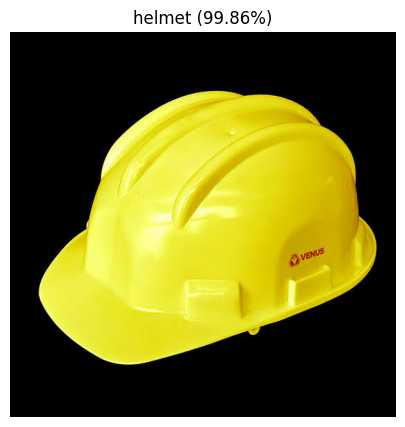

In [22]:

def show_prediction(image_path):

    image = Image.open(image_path).convert("RGB")

    image_for_model = image.resize(IMG_SIZE)

    image_array = np.array(image_for_model)
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    index = np.argmax(probabilities)

    plt.figure(figsize=(7, 5))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"{class_names[index]} "
        f"({probabilities[index] * 100:.2f}%)"
    )

    plt.show()


# Example:
show_prediction("/content/images (2).jpeg")


## 22. Save the Final Model

In [ ]:

MODEL_PATH = WORK / "PPE_Multiclass_Classifier_MobileNetV2.keras"
CLASS_NAMES_PATH = WORK / "class_names.txt"

model.save(MODEL_PATH)

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(class_names))

print("Model saved to:", MODEL_PATH)
print("Class names saved to:", CLASS_NAMES_PATH)



## 23. Project Summary

### Project Title

**Multiclass PPE Classification Using Transfer Learning**

### Objective

To classify PPE-related image crops into multiple construction-safety classes using a pretrained MobileNetV2 convolutional neural network.

### Methodology

1. Download the Construction PPE dataset.
2. Read YOLO annotations.
3. Extract bounding-box crops.
4. Organize crops into class folders.
5. Apply image augmentation.
6. Use MobileNetV2 pretrained on ImageNet.
7. Train the classification head.
8. Fine-tune the later layers.
9. Evaluate using:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - Confusion matrix
10. Save the trained model.

### Final Pipeline

**Construction PPE Dataset → YOLO Annotation Cropping → Classification Dataset → Data Augmentation → MobileNetV2 → Softmax → PPE Class**

This approach is substantially simpler to train and explain than the original full object-detection and PPE-compliance pipeline.


In [25]:
import gradio as gr
from tensorflow import keras
from PIL import Image
import numpy as np

# Reload the saved model + class names so this can also be run on its
# own (e.g. after restarting the runtime) without retraining.
inference_model = keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    inference_class_names = [line.strip() for line in f if line.strip()]


def classify_ppe_image(pil_image, top_k=5):
    if pil_image is None:
        return {}

    image = pil_image.convert("RGB").resize(IMG_SIZE)
    image_array = np.expand_dims(np.array(image), axis=0).astype("float32")

    # No manual normalization here - the model's own Rescaling layer
    # (added when the model was built) handles that internally.
    probabilities = inference_model.predict(image_array, verbose=0)[0]

    top_indices = np.argsort(probabilities)[::-1][:top_k]

    return {
        inference_class_names[i]: float(probabilities[i])
        for i in top_indices
    }


demo = gr.Interface(
    fn=classify_ppe_image,
    inputs=gr.Image(type="pil", label="Upload a PPE image"),
    outputs=gr.Label(num_top_classes=5, label="Predicted class"),
    title="PPE Classifier",
    description=(
        "Upload a photo (ideally already cropped close to one person/item, "
        "similar to the training crops) to classify PPE compliance."
    ),
)

# share=True also gives you a public link (useful in Colab); set to
# False if you only want it running locally.
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f59e5a82525189351c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
